# Clustering and predicting relationships among gamers on Steam

STEP 1: Problem Understanding

Bài toán: Phân cụm cộng đồng người dùng và dự đoán liên kết giữa các người chơi

Loại bài toán: Phân cụm, dự đoán liên kết

Đầu vào: (features) dữ liệu thông tin của người dùng được crawl trên trang cá nhân của từng người ( 1500 người)

Output : (target): - tự động nhóm người dùng có hành vi/đặc điểm cộng đồng tương tự lại với nhau.
                   - cho biết hai người bất kỳ trong tương lai có kết bạn hay không.


Mục tiêu: thành công trong phân cụm cộng đồng, dự đoán sự liên kết dựa trên các yếu tố khai thác được trong dữ liệu 

------------------------------------------------------------------------------------------------------------

# STEP 2: Crawl Data.

Mục đích: Lấy dữ liệu thông tin người dùng tren steam

Dữ liệu được thu thập thông qua Steam Web API, một giao diện cho phép truy cập trực tiếp vào các thông tin công khai của người dùng và hệ sinh thái trên nền tảng Steam.

 vì Steam Web API không cho phép cào dữ liệu một cách ngẫu nhiên, nên cần đưa vào steam id của một người dùng nào đó trên steam để API tìm, khi đó chương trình sẽ dẫn đến trang cá nhân của người đó. ở đây nhóm em đưa vào 2 id là 2 id của 2 streamer nổi tiếng là Độ Mixi và Xemexis. nên sẽ dễ dàng hơn vì 2 người này có độ bao phủ cao, nhiều bạn bè

Trong một trang cá nhân bao gồm nhiều thông tin như: id, tên, thời gian tham gia, nước, khu vực, số thành tựu, số trò chơi đã có, list bạn bè và nhóm tham gia,… Để thu thập các thông tin trên ta sử dụng API endpoints( bao gồm các biến mà steam cung cấp để lấy các dữ liệu tương ứng):

GetFriendList : Lấy danh sách bạn bè của một người
GetUserGroupList : Lấy danh sách nhóm của một người
get_owned_games : Lấy danh sách game của một người
…
Và chỉ thu thập thông tin của người nào đặt trạng thái là public, các account để Private thì bo qua. Sau khi thu thập xong một trang cá nhân thì chương trình sẽ chuyển hướng đến danh sách bạn bè của người đó, thực hiện truy cập vào trang cá nhân của người đó và tiếp tục thu thập. Chương trình sẽ tiếp tục thu thập theo hướng đó cho tới khi đủ 2000 người dùng public


## Bước 1: Chuẩn bị môi trường 

In [1]:
import json
import pandas as pd
import re
import os
from pathlib import Path
import time
import hashlib
from itertools import islice
import requests
import networkx as nx
from dotenv import load_dotenv
import  random
from itertools import islice
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import networkx as nx
from sklearn.cluster import KMeans, DBSCAN
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from itertools import combinations








## Bước 2: API key

In [5]:
# Load API key
load_dotenv()
API_KEY = os.getenv("STEAM_API_KEY")
if not API_KEY:
    raise SystemExit("Please set STEAM_API_KEY in environment or .env file")
BASE = "https://api.steampowered.com"
CACHE_DIR = Path("steam_cache")
CACHE_DIR.mkdir(exist_ok=True)

DELAY_BETWEEN_REQUESTS = 0.5
BATCH_SIZE = 50
MAX_ACHIEVEMENTS_APPS = 3
REQUEST_TIMEOUT = 15


## Bước 3: STEAM CRAWLER 
- Cache để tránh request trùng
- API request với backoff, skip private
- Các endpoint Steam:  friends, owned games, recently played, groups, achievements
- BFS crawl nhiều batch, skip user/private, merge cuối cùng ( để tránh bị khóa acc steam)


In [6]:
CACHE_DIR = Path("steam_cache")
CACHE_DIR.mkdir(exist_ok=True)

def cache_key(endpoint, params):
    s = endpoint + json.dumps(params, sort_keys=True)
    return hashlib.sha1(s.encode("utf-8")).hexdigest()

def cache_load(endpoint, params):
    k = cache_key(endpoint, params)
    p = CACHE_DIR / f"{k}.json"
    if p.exists():
        return json.loads(p.read_text(encoding="utf-8"))
    return None

def cache_save(endpoint, params, data):
    k = cache_key(endpoint, params)
    p = CACHE_DIR / f"{k}.json"
    p.write_text(json.dumps(data, ensure_ascii=False, indent=2), encoding="utf-8")

DELAY_MIN = 1.0
DELAY_MAX = 2.0
REQUEST_TIMEOUT = 15
CHECKPOINT_EVERY = 50
BASE = "https://api.steampowered.com"
API_KEY = os.getenv("STEAM_API_KEY")

def api_get(endpoint, params, use_cache=True):
    params = dict(params)
    params["key"] = API_KEY
    if use_cache:
        cached = cache_load(endpoint, params)
        if cached is not None:
            return cached

    url = f"{BASE}/{endpoint}"
    backoff = 1.0
    for _ in range(6):
        r = requests.get(url, params=params, timeout=REQUEST_TIMEOUT)
        if r.status_code == 200:
            data = r.json()
            cache_save(endpoint, params, data)
            time.sleep(random.uniform(DELAY_MIN, DELAY_MAX))
            return data
        elif r.status_code in (429, 503):
            time.sleep(backoff + random.uniform(0.1, 0.5))
            backoff *= 2
        elif r.status_code in (401, 403):
            return {"private": True}
        else:
            return None
    return None

def get_friend_list(steamid):
    endpoint = "ISteamUser/GetFriendList/v0001/"
    params = {"steamid": steamid, "relationship": "friend"}
    data = api_get(endpoint, params)
    if data and data.get("private"):
        return []
    return [f.get("steamid") for f in data.get("friendslist", {}).get("friends", [])] if data else []

def get_owned_games(steamid):
    endpoint = "IPlayerService/GetOwnedGames/v0001/"
    params = {"steamid": steamid, "include_appinfo": 1, "include_played_free_games": 1, "format": "json"}
    data = api_get(endpoint, params)
    if data and data.get("private"):
        return {}
    return data.get("response", {}) if data else {}

def get_recently_played(steamid):
    endpoint = "IPlayerService/GetRecentlyPlayedGames/v0001/"
    params = {"steamid": steamid}
    data = api_get(endpoint, params)
    if data and data.get("private"):
        return {}
    return data.get("response", {}) if data else {}

def get_user_groups(steamid):
    endpoint = "ISteamUser/GetUserGroupList/v1/"
    params = {"steamid": steamid}
    data = api_get(endpoint, params)
    if data and data.get("private"):
        return []
    return data.get("response", {}).get("groups", []) if data else []

def get_player_summaries(steamids):
    endpoint = "ISteamUser/GetPlayerSummaries/v0002/"
    params = {"steamids": ",".join(steamids)}
    data = api_get(endpoint, params)
    return data.get("response", {}).get("players", []) if data else []

def save_profiles(profiles, out_prefix="steam_output"):
    path = f"{out_prefix}_profiles.json"
    with open(path, "w", encoding="utf-8") as f:
        json.dump(profiles, f, indent=2, ensure_ascii=False)

def crawl(seed_ids, depth=1, max_users=1000, max_apps_per_user=3, visited_global=None, save_prefix="steam_output"):
    visited_global = visited_global or set()
    queue = [(s, 0) for s in seed_ids]
    profiles = {}

    while queue and len(visited_global) < max_users:
        steamid, d = queue.pop(0)
        if steamid in visited_global or d > depth:
            continue
        if not steamid.isdigit():
            continue

        players = get_player_summaries([steamid])
        if not players:
            visited_global.add(steamid)
            continue

        player = players[0]
        visited_global.add(steamid)

        profile = {
            "steamid": steamid,
            "personaname": player.get("personaname", ""),
            "loccountrycode": player.get("loccountrycode", ""),
            "timecreated": player.get("timecreated", None),
        }

        friends = get_friend_list(steamid)
        owned = get_owned_games(steamid)
        recent = get_recently_played(steamid)
        groups = get_user_groups(steamid)

        profile["friends"] = friends
        profile["owned_game_count"] = owned.get("game_count", 0)
        profile["recent_count"] = recent.get("total_count", 0)
        profile["groups"] = [g.get("groupid64") for g in groups] if groups else []

        apps = owned.get("games", []) if isinstance(owned, dict) else []
        top_apps = sorted(apps, key=lambda x: x.get("playtime_forever", 0), reverse=True)[:max_apps_per_user]
        profile["top_apps"] = [a.get("appid") for a in top_apps]

        profiles[steamid] = profile

        for f in friends:
            if f not in visited_global and d + 1 <= depth:
                queue.append((f, d + 1))

        if len(visited_global) % CHECKPOINT_EVERY == 0:
            save_profiles(profiles, out_prefix=f"{save_prefix}_partial")

    save_profiles(profiles, out_prefix=save_prefix)
    return profiles, visited_global

if __name__ == "__main__":
    SEEDS = ["76561198294300457", "76561197973974836"]
    profiles, visited = crawl(SEEDS, depth=2, max_users=2000, max_apps_per_user=3, save_prefix="steam_output")


Crawling 76561198294300457 (depth 0) | Visited 0/5000
Crawling 76561197973974836 (depth 0) | Visited 1/5000
Crawling 76561197993609350 (depth 1) | Visited 2/5000
Crawling 76561198046562139 (depth 1) | Visited 3/5000
Crawling 76561198061953477 (depth 1) | Visited 4/5000
Crawling 76561198062226249 (depth 1) | Visited 5/5000
Crawling 76561198076766555 (depth 1) | Visited 6/5000
Crawling 76561198077186687 (depth 1) | Visited 7/5000
Crawling 76561198097199951 (depth 1) | Visited 8/5000
Crawling 76561198109776027 (depth 1) | Visited 9/5000
Crawling 76561198110181817 (depth 1) | Visited 10/5000
Crawling 76561198116685130 (depth 1) | Visited 11/5000
Crawling 76561198120611517 (depth 1) | Visited 12/5000
Crawling 76561198128339070 (depth 1) | Visited 13/5000
Crawling 76561198134815732 (depth 1) | Visited 14/5000
Crawling 76561198135035013 (depth 1) | Visited 15/5000
Crawling 76561198138224835 (depth 1) | Visited 16/5000
[PRIVATE] skip: {'steamid': '76561198138224835', 'relationship': 'friend', 

--------------------------------------------------------------------------------------------------------------------------

# STEP 3: Data Understanding.
Mục đích: Hiểu rõ cấu trúc đặc điểm và tiền xử lý dữ liệu 
Bao gồm
Data Overview: Kiểm tra tổng quan dữ liệu

Merge data : Gộp dữ liệu

Chỉnh sửa hoàn thiện bảng dữ liệu hoàn chỉnh

Xem thông tin, vẽ biểu đồ liên kết xã hội



### Xem cấu trúc dữ liệu

In [16]:
# Cấu trúc của dữ liệu sau khi crawl
path = "backup/backup_steamcache"
for root, dirs, files in os.walk(path):
    level = root.replace(path, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = "    " * (level + 1)
    for f in files[:2]:  # chỉ in 2 file đầu tiên
        print(f"{subindent}{f}")
    if len(files) > 2:
        print(f"{subindent}... ({len(files) - 2} more files)")




backup_steamcache/
    achievements/
        0016639dbc02846d6270130c48ed50627ee98b68.json
        01060e28944271a46ff00f7486e7a0e12881a3d9.json
        ... (489 more files)
    friends/
        00759b3c8e7eaadeaea1b002e54536d5994470fa.json
        007c1e31657ff690fbe9010b0ede230a7a31b03a.json
        ... (1581 more files)
    games/
        0027bacf933eb9c2534b331a513348d1ff6cbe73.json
        004db018339c8e399b9a6a4aede8b7e7ddfe96fc.json
        ... (1500 more files)
    groups/
        009149f54fd887cfa28c99b2bf242057ea1fb49c.json
        00adc075b741c898752024afa97d4146e42ee64a.json
        ... (1798 more files)
    summaries/
        00138eb1126f1b3ac67152f0aef4f18866b4116d.json
        00504a1bcd8d280899ce3183981157cb15e91d6b.json
        ... (1949 more files)


In [19]:
# đặt lại tên user ( 1 2 3 4,...)
df = pd.read_csv('steam_cache/csv/profiles_users1.csv')
unique_ids = df['steamid'].astype(str).str.strip().unique()
user_id_map = {uid: f"User{i+1}" for i, uid in enumerate(unique_ids)}

df['user_id'] = df['steamid'].map(user_id_map)

df = df[['user_id', 'steamid', 'profilestate', 'personaname', 'avatarfull', 'personastate',
         'realname', 'primaryclanid', 'timecreated', 'loccountrycode', 'locstatecode']]


### GỘP CÁC FILE LẠI THÀNH 1 FILE 

In [ ]:

df= pd.read_csv('profiles_users.csv')
df_achievements = pd.read_csv('achievements.csv')
df_game=pd.read_csv('game.csv')
df_group=pd.read_csv('group.csv')

df['steamid'] = df['steamid'].astype(str).str.strip()
df_achievements['steamid'] = df_achievements['steamid'].astype(str).str.strip()
df_game_counts = df_achievements.groupby(['steamid', 'gameName']).size().reset_index(name='count_per_game')
df_achievements_summary = df_game_counts.groupby('steamid').agg(
    total_achievements=('count_per_game', 'sum'),
    game_achievements_summary=('gameName', lambda x: ' | '.join(x + ' (' + df_game_counts.loc[x.index, 'count_per_game'].astype(str) + ')'))
).reset_index()

df_merged = pd.merge(df, df_achievements_summary, on='steamid', how='left')

df_merged.to_csv('profiles_users.csv', index=False)


### XÓA CÁC TRƯỜNG DỮ LIỆU KHÔNG CẦN THIẾT

In [ ]:
drop_cols = [
    "realname", "profilestate", "personastate", "primaryclanid",
    "game_achievements_summary", "total_playtime_forever", "avatarfull"
]
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

### KHAI THÁC VÀ TẠO THÊM CÁC TRƯỜNG DỮ LIỆU

In [ ]:
# tên tỉnh ( mã khu vực)
MAPPING_TINH = {
    1: 'Hà Giang', 2: 'Cao Bằng', 3: 'Bắc Kạn', 4: 'Tuyên Quang', 5: 'Lạng Sơn', 
    6: 'Thái Nguyên', 7: 'Yên Bái', 8: 'Lào Cai', 9: 'Điện Biên', 10: 'Lai Châu', 
    11: 'Sơn La', 12: 'Hòa Bình', 13: 'Phú Thọ', 14: 'Vĩnh Phúc', 15: 'Bắc Ninh', 
    16: 'Quảng Ninh', 17: 'Bắc Giang', 18: 'Hải Dương', 19: 'Hưng Yên', 20: 'Thái Bình', 
    21: 'Nam Định', 22: 'Ninh Bình', 23: 'Thanh Hóa', 24: 'Nghệ An', 25: 'Hà Tĩnh', 
    26: 'Quảng Bình', 27: 'Quảng Trị', 28: 'Thừa Thiên Huế', 29: 'Thành phố Hà Nội', 
    30: 'Thành phố Đà Nẵng', 31: 'Quảng Nam', 32: 'Quảng Ngãi', 33: 'Bình Định', 
    34: 'Phú Yên', 35: 'Khánh Hòa', 36: 'Ninh Thuận', 37: 'Bình Thuận', 38: 'Kon Tum', 
    39: 'Thành phố Cần Thơ', 40: 'Sóc Trăng', 41: 'Bạc Liêu', 42: 'Cà Mau', 43: 'Gia Lai', 
    44: 'Đắk Lắk', 45: 'Đắk Nông', 46: 'Lâm Đồng', 47: 'Bình Phước', 48: 'Tây Ninh', 
    49: 'Đồng Nai', 50: 'Bà Rịa - Vũng Tàu', 51: 'Thành phố Hồ Chí Minh', 
    52: 'Long An', 53: 'Tiền Giang', 54: 'Bến Tre', 55: 'Trà Vinh', 56: 'Vĩnh Long', 
    57: 'Đồng Tháp', 58: 'An Giang', 59: 'Kiên Giang', 60: 'Thành phố Hải Phòng', 
    61: 'Hậu Giang', 62: 'Bạc Liêu', 63: 'Sóc Trăng'
}
df['ten_tinh'] = pd.to_numeric(df['locstatecode'].astype(str).str.extract(r'(\d+)')[0], errors='coerce').astype('Int64').map(MAPPING_TINH)

In [ ]:

# 2. avg_playtime_per_game   tg chơi mỗi game ( tổng tg chơi(đổi ra giờ) / tổng game)
df["avg_playtime_per_game"] = df["total_playtime_hours"] / df["total_games"].replace(0, 1)

# 3. account_age_years # tuổi của acc
df["account_age_years"] = df["account_age_days"] / 365

# 4. is_old_account (lớn hơn 5 năm)
df["is_old_account"] = (df["account_age_years"] > 5).astype(int)

# 5. is_VN # là người VN (countrycode)
df["is_VN"] = (df["loccountrycode"] == "VN").astype(int)

# 6. region: gom tỉnh thành vào 3 miền (Bắc/Trung/Nam) tên_tinh
north = [
    "Hà Giang","Cao Bằng","Bắc Kạn","Tuyên Quang","Lạng Sơn","Thái Nguyên",
    "Yên Bái","Lào Cai","Điện Biên","Lai Châu","Sơn La","Hòa Bình",
    "Phú Thọ","Vĩnh Phúc","Bắc Ninh","Quảng Ninh","Bắc Giang","Hải Dương",
    "Hưng Yên","Thái Bình","Nam Định","Ninh Bình","Thành phố Hà Nội","Thành phố Hải Phòng"
]
central = [
    "Thanh Hóa","Nghệ An","Hà Tĩnh","Quảng Bình","Quảng Trị","Thừa Thiên Huế",
    "Thành phố Đà Nẵng","Quảng Nam","Quảng Ngãi","Bình Định","Phú Yên",
    "Khánh Hòa","Ninh Thuận","Bình Thuận","Kon Tum","Gia Lai","Đắk Lắk",
    "Đắk Nông","Lâm Đồng"
]
south = [
    "Thành phố Hồ Chí Minh","Bình Phước","Tây Ninh","Bình Dương","Đồng Nai",
    "Bà Rịa - Vũng Tàu","Long An","Tiền Giang","Bến Tre","Trà Vinh","Vĩnh Long",
    "Đồng Tháp","An Giang","Kiên Giang","Cần Thơ","Hậu Giang","Sóc Trăng",
    "Bạc Liêu","Cà Mau"
]

def map_region(province):
    if province in north:
        return "0" # Bắc
    elif province in central:
        return "1" # Trung
    elif province in south:
        return "2" # Nam
    else:
        return "3" # Nước Ngoài

df["region"] = df["ten_tinh"].apply(map_region)

# 7. group_count: số lượng group thực tế
df["group_count"] = df["group_names"].apply(lambda x: len(str(x).split("|")) if pd.notna(x) else 0)

# 8. social_factor = (new_group_count + group_count) / account_age_years # mức đọ xã hội ( tổng nhóm / thời gian hoạt động)
df["social_factor"] = (df["new_group_count"] + df["group_count"]) / df["account_age_years"].replace(0, 1)

# tổng số bạn bè ( danh sách bb)
df = df.drop(columns=[c for c in df.columns if 'friend_count' in c and ';' in c])
df["friend_count"] = df["friend_steamids_list"].fillna("").apply(lambda x: len(x.split("|")) if x else 0)
df.to_csv("data_users.csv", index=False, encoding="utf-8-sig")



### Liên Kết Xã Hội

- in ra số node và cạnh
- vẽ đò thị liên kết
- vẽ đồ thị tương quan

Số node: 1482
Số cạnh: 57796


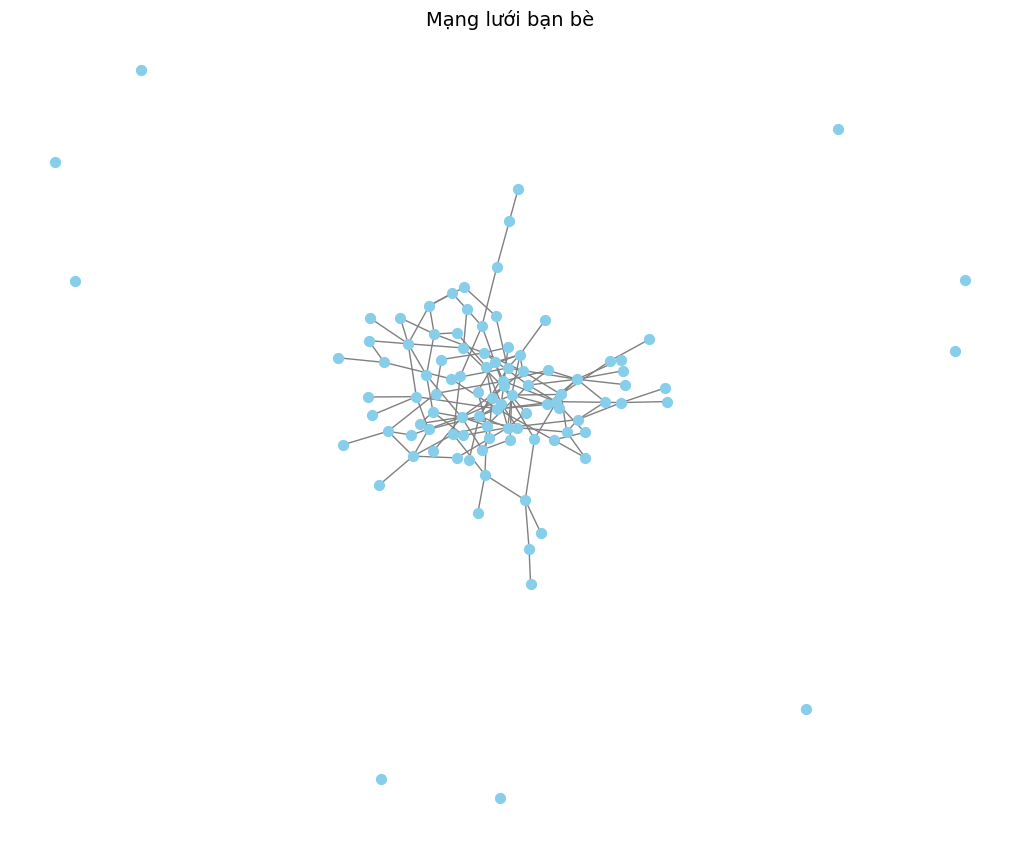

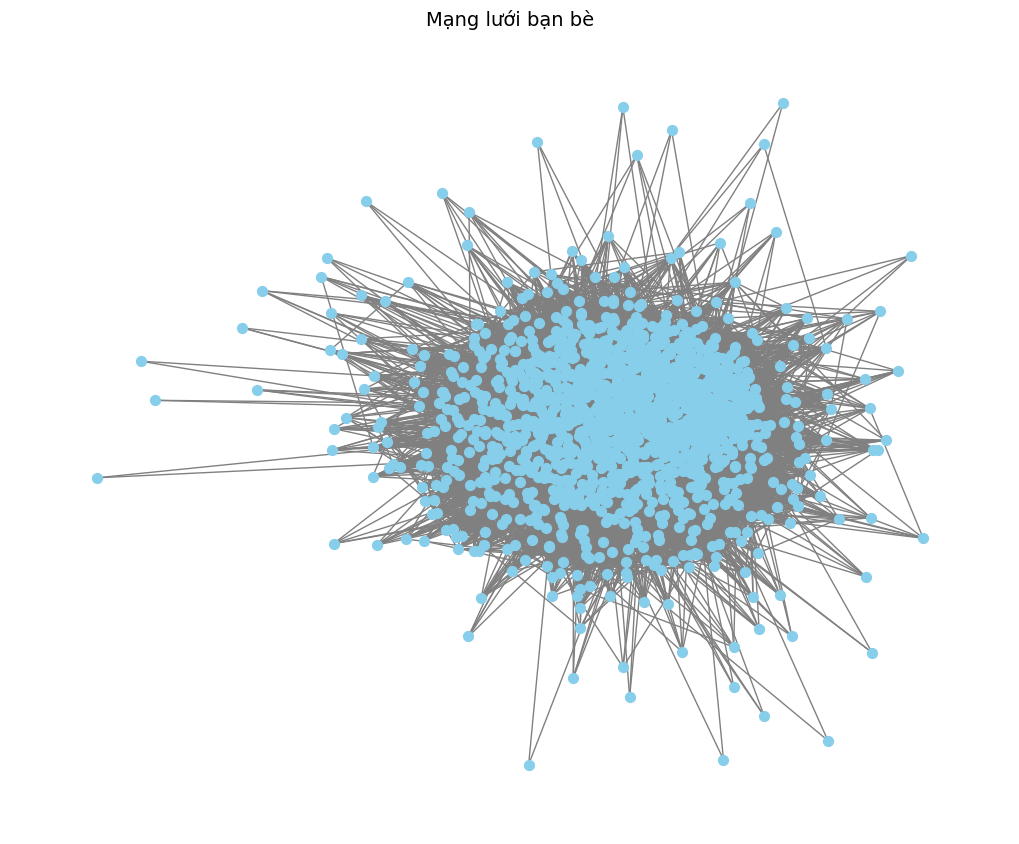

In [4]:
df = pd.read_csv('data_users.csv')
valid_users = set(df['steamid'].astype(str).str.strip())
G = nx.Graph()

# Duyệt từng người chơi
for _, row in df.iterrows():
    user = str(row['steamid']).strip()
    G.add_node(user)
    if pd.notna(row['friend_steamids_list']):
        friends = [f.strip().strip("[]'\" ") for f in str(row['friend_steamids_list']).split('|')]
        for f in friends:
            if f in valid_users:  
                G.add_edge(user, f)
print("Số node:", G.number_of_nodes())
print("Số cạnh:", G.number_of_edges())

sub_nodes = list(df['steamid'].astype(str))[:100]
H = G.subgraph(sub_nodes)
plt.figure(figsize=(10, 8))
nx.draw(H, node_size=50, node_color='skyblue', edge_color='gray', with_labels=False)
plt.title("Mạng lưới bạn bè (100 người)", fontsize=14)
plt.show()

sub_nodes = list(df['steamid'].astype(str))
H = G.subgraph(sub_nodes)
plt.figure(figsize=(10, 8))
nx.draw(H, node_size=50, node_color='skyblue', edge_color='gray', with_labels=False)
plt.title("Mạng lưới bạn bè", fontsize=14)
plt.show()


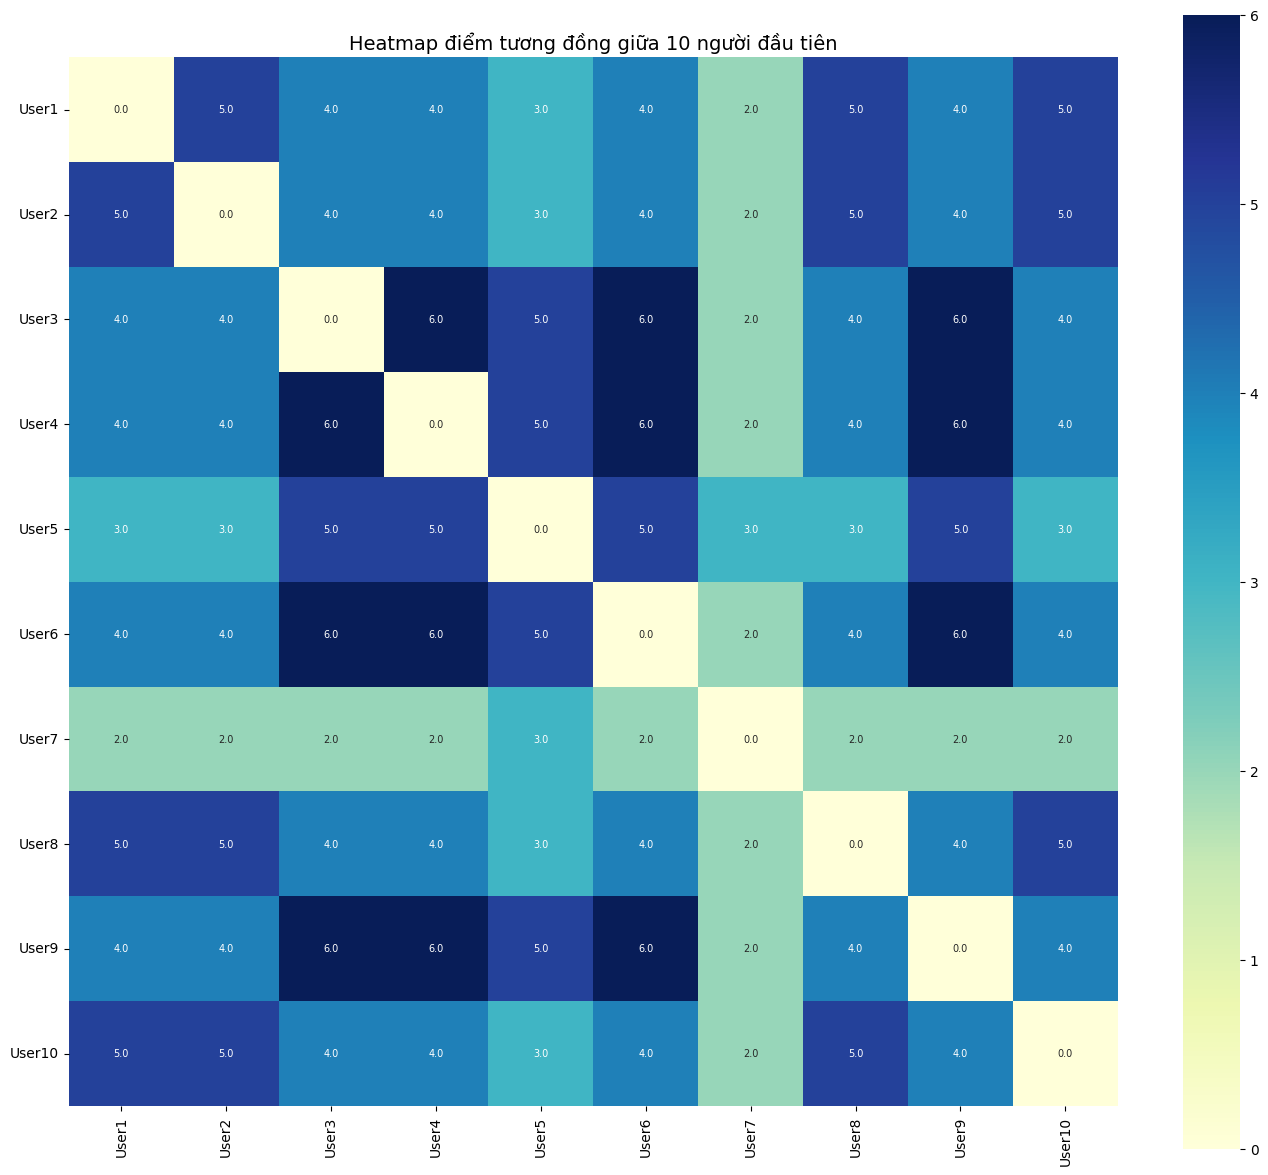

In [11]:
def to_set(x):
    try:
        if pd.isna(x) or x == "[]":
            return set()
        return set(str(x).replace("[","").replace("]","").replace("'","").split(","))
    except:
        return set()

df["friend_steamids_list"] = df["friend_steamids_list"].apply(to_set) # + 0.2 
features = [
    "loccountrycode", "region", "ten_tinh",
     "in_game_group", "in_platform_group", "in_fan_group" # +1
]
df.set_index("user_id", inplace=True, drop=False)

def link_score(u, v):
    score = 0
    for f in features:
        if df.loc[u, f] == df.loc[v, f]:
            score += 1
    # Tính bạn chung
    common_friends = df.loc[u, "friend_steamids_list"] & df.loc[v, "friend_steamids_list"]
    score += 0.2 * len(common_friends)
    return score

n = len(df)
sim_matrix = np.zeros((n, n))
user_ids = df["user_id"].tolist()

for i, j in combinations(range(n), 2):
    s = link_score(user_ids[i], user_ids[j])
    sim_matrix[i, j] = sim_matrix[j, i] = s

plt.figure(figsize=(14, 12))
sns.heatmap(
    sim_matrix, cmap="YlGnBu", square=True,
    xticklabels=user_ids, yticklabels=user_ids,
    annot=True, fmt=".1f", 
    annot_kws={"size": 7}
)
plt.title("Heatmap điểm tương đồng giữa 10 người đầu tiên", fontsize=14)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


-----------------------------------------------------------------------------------------------------

# STEP 4: Feature Engineering ( Kỹ thuật đặc trưng ) 
Chuẩn bị và biến đổi dữ liệu đầu vào thành dạng tốt nhất cho mô hình phân cụm.

- Xử lý dữ liệu thiếu
- Xử lý Outliers
- Chuẩn hóa dữ liệu



### TÌM DỮ LIỆU THIẾU


In [ ]:

missing_data = df.isnull().sum()
columns_with_missing = missing_data[missing_data > 0]

print("Các cột có dữ liệu thiếu:")
print(columns_with_missing)

Các cột có dữ liệu thiếu:
personaname                     1
filtered_all_groups_gid_30      1
group_names                     1
timecreated                     1
loccountrycode                  1
locstatecode                    1
ten_tinh                      580
total_achievements              1
is_old_account                  1
is_VN                           1
friend_steamids_list            1
dtype: int64

Chi tiết tỷ lệ thiếu:
personaname: 0.07% (1 giá trị thiếu)
filtered_all_groups_gid_30: 0.07% (1 giá trị thiếu)
group_names: 0.07% (1 giá trị thiếu)
timecreated: 0.07% (1 giá trị thiếu)
loccountrycode: 0.07% (1 giá trị thiếu)
locstatecode: 0.07% (1 giá trị thiếu)
ten_tinh: 39.11% (580 giá trị thiếu)
total_achievements: 0.07% (1 giá trị thiếu)
is_old_account: 0.07% (1 giá trị thiếu)
is_VN: 0.07% (1 giá trị thiếu)
friend_steamids_list: 0.07% (1 giá trị thiếu)


In [ ]:
#  2: Xử lý missing values
# Numeric / state
df['profilestate'] = df['profilestate'].fillna(0)
df['total_games'] = df['total_games'].fillna(df['total_games'].median())
df['total_groups'] = df['total_groups'].fillna(0)
df['ten_tinh'] = df['ten_tinh'].fillna('UNKNOWN')

# String / object
df['personaname'] = df['personaname'].fillna('Unknown')
df['all_groups_gid'] = df['all_groups_gid'].fillna('[]')

# Location
df['loccountrycode'] = df['loccountrycode'].fillna('VN')
def fill_locstate(row):
    if row['loccountrycode'] == 'VN':
        if pd.isnull(row['locstatecode']):
            return str(random.randint(1, 63))  # VN có 63 tỉnh
        else:
            return row['locstatecode']
    else:
        return 'Unknown'

df['locstatecode'] = df.apply(fill_locstate, axis=1)

# Achievements
df['total_achievements'] = df['total_achievements'].fillna(0)
df['game_achievements_summary'] = df['game_achievements_summary'].where(df['game_achievements_summary'].notnull(), None)

#  3: Chuyển timecreated sang datetime 
df['timecreated'] = pd.to_datetime(df['timecreated'], errors='coerce')
median_time = df['timecreated'].median()
df['timecreated'] = df['timecreated'].fillna(median_time)

#  4: Tạo feature numeric account_age_days 
df['account_age_days'] = (pd.Timestamp('now') - df['timecreated']).dt.days



### Xử lý OUTLIERS

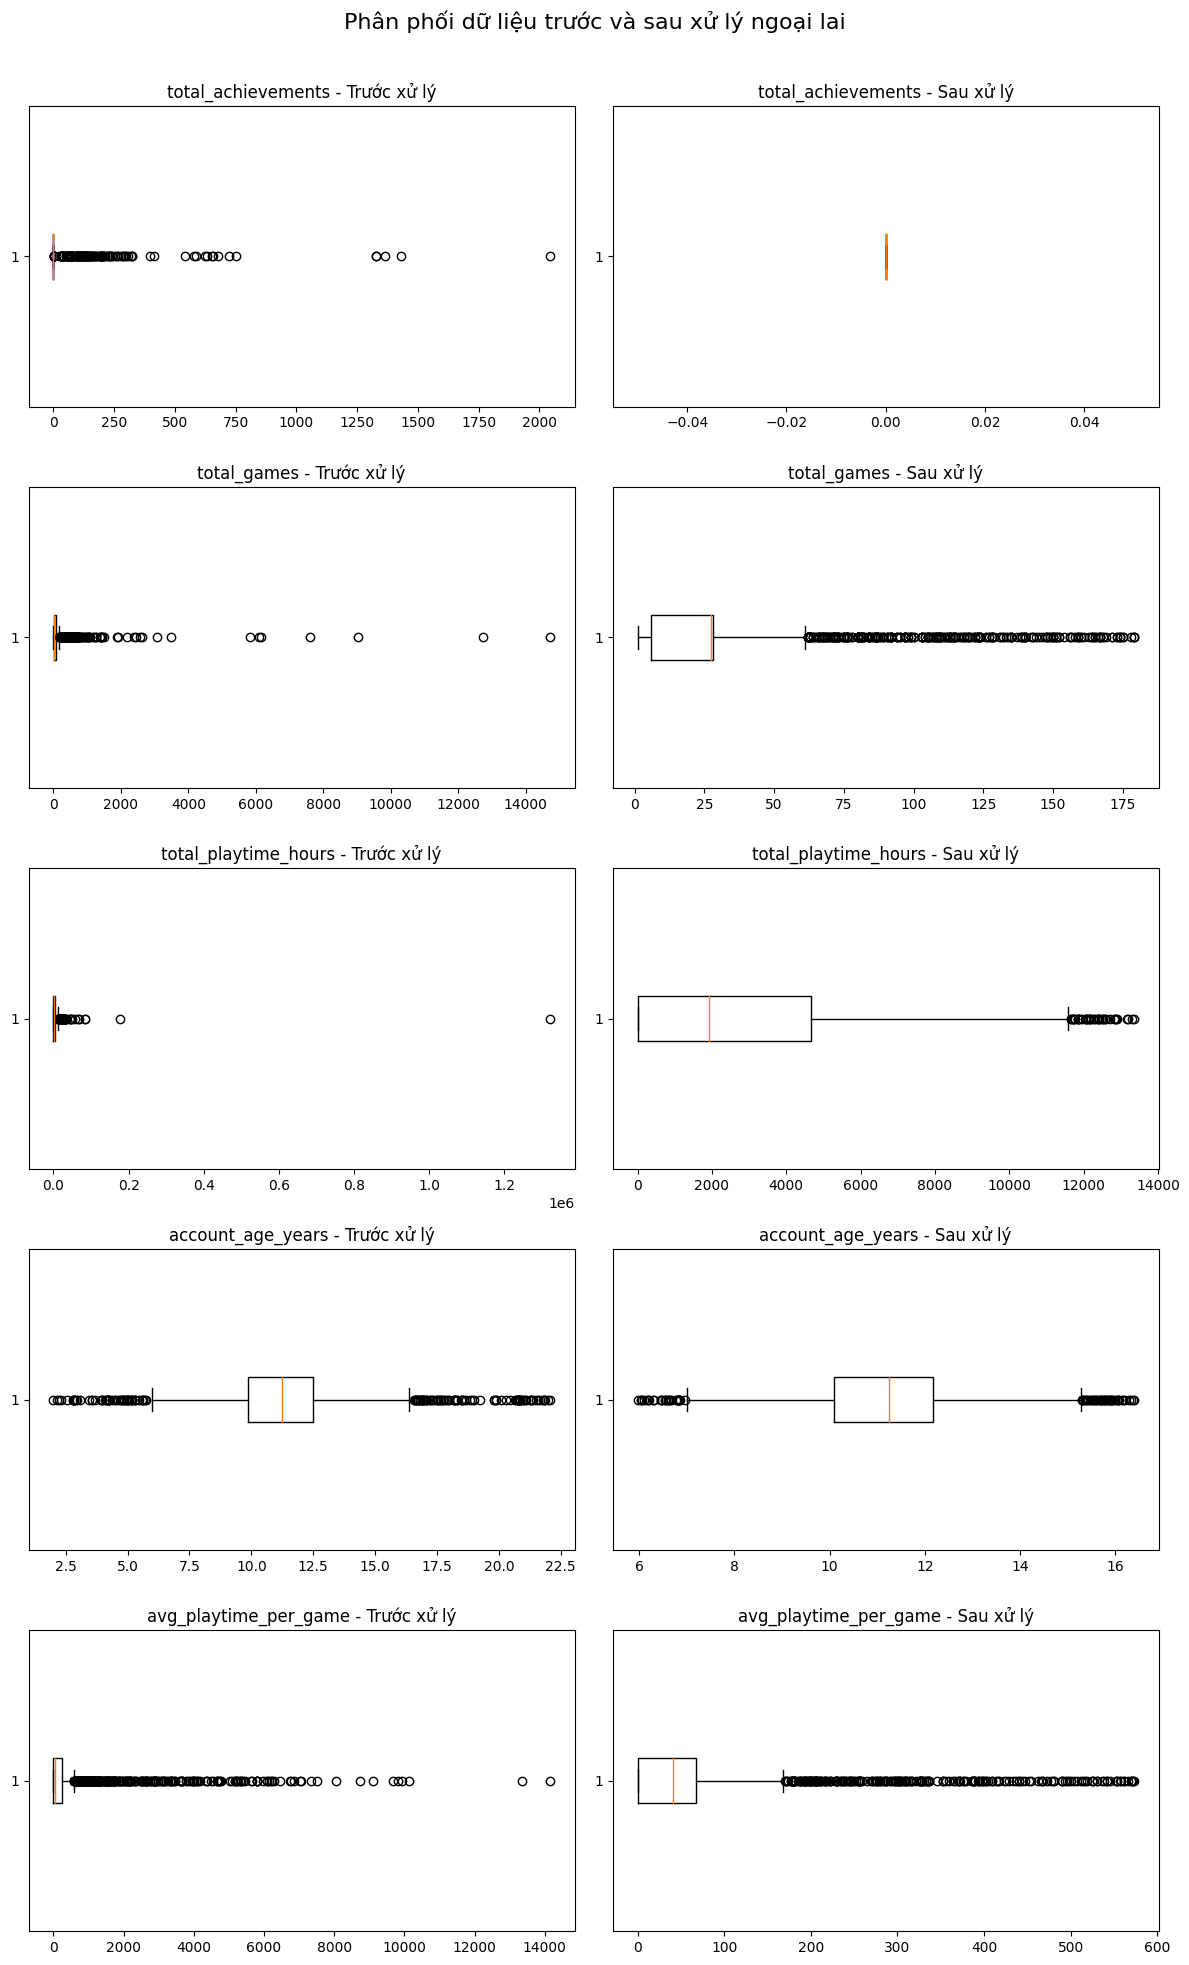

In [3]:
NUMERIC_COLS = [
    'total_achievements', 'total_games',
    'total_playtime_hours', 'account_age_years', 'avg_playtime_per_game'
]

df_before = df.copy()
for col in NUMERIC_COLS:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    median = df[col].median()

    # Thay giá trị ngoại lai bằng trung vị
    df.loc[(df[col] < lower) | (df[col] > upper), col] = median
# 2 VẼ BIỂU ĐỒ BOX PLOT so sánh
fig, axes = plt.subplots(nrows=len(NUMERIC_COLS), ncols=2, figsize=(12, 4 * len(NUMERIC_COLS)))
fig.suptitle("Phân phối dữ liệu trước và sau xử lý ngoại lai", fontsize=16)

for i, col in enumerate(NUMERIC_COLS):
    # Biểu đồ trước xử lý
    axes[i, 0].boxplot(df_before[col].dropna(), vert=False)
    axes[i, 0].set_title(f"{col} - Trước xử lý")

    # Biểu đồ sau xử lý
    axes[i, 1].boxplot(df[col].dropna(), vert=False)
    axes[i, 1].set_title(f"{col} - Sau xử lý")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


### Chuẩn Hóa Dữ Liệu

In [5]:

df = pd.read_csv('data_users.csv')
numeric_cols = [
    'total_playtime_hours', 'total_games', 'avg_playtime_per_game',
    'friend_count', 'group_count', 'new_group_count', 'social_factor',
    'account_age_days', 'account_age_years'
]
existing_cols = [col for col in numeric_cols if col in df.columns]
scaler = StandardScaler()
df = df.copy()
df[existing_cols] = scaler.fit_transform(df[existing_cols])

------------------------------------------------------------------------------------------------------------------------

# PHÂN TÍCH VÀ TRỰC QUAN HÓA DỮ LIỆU

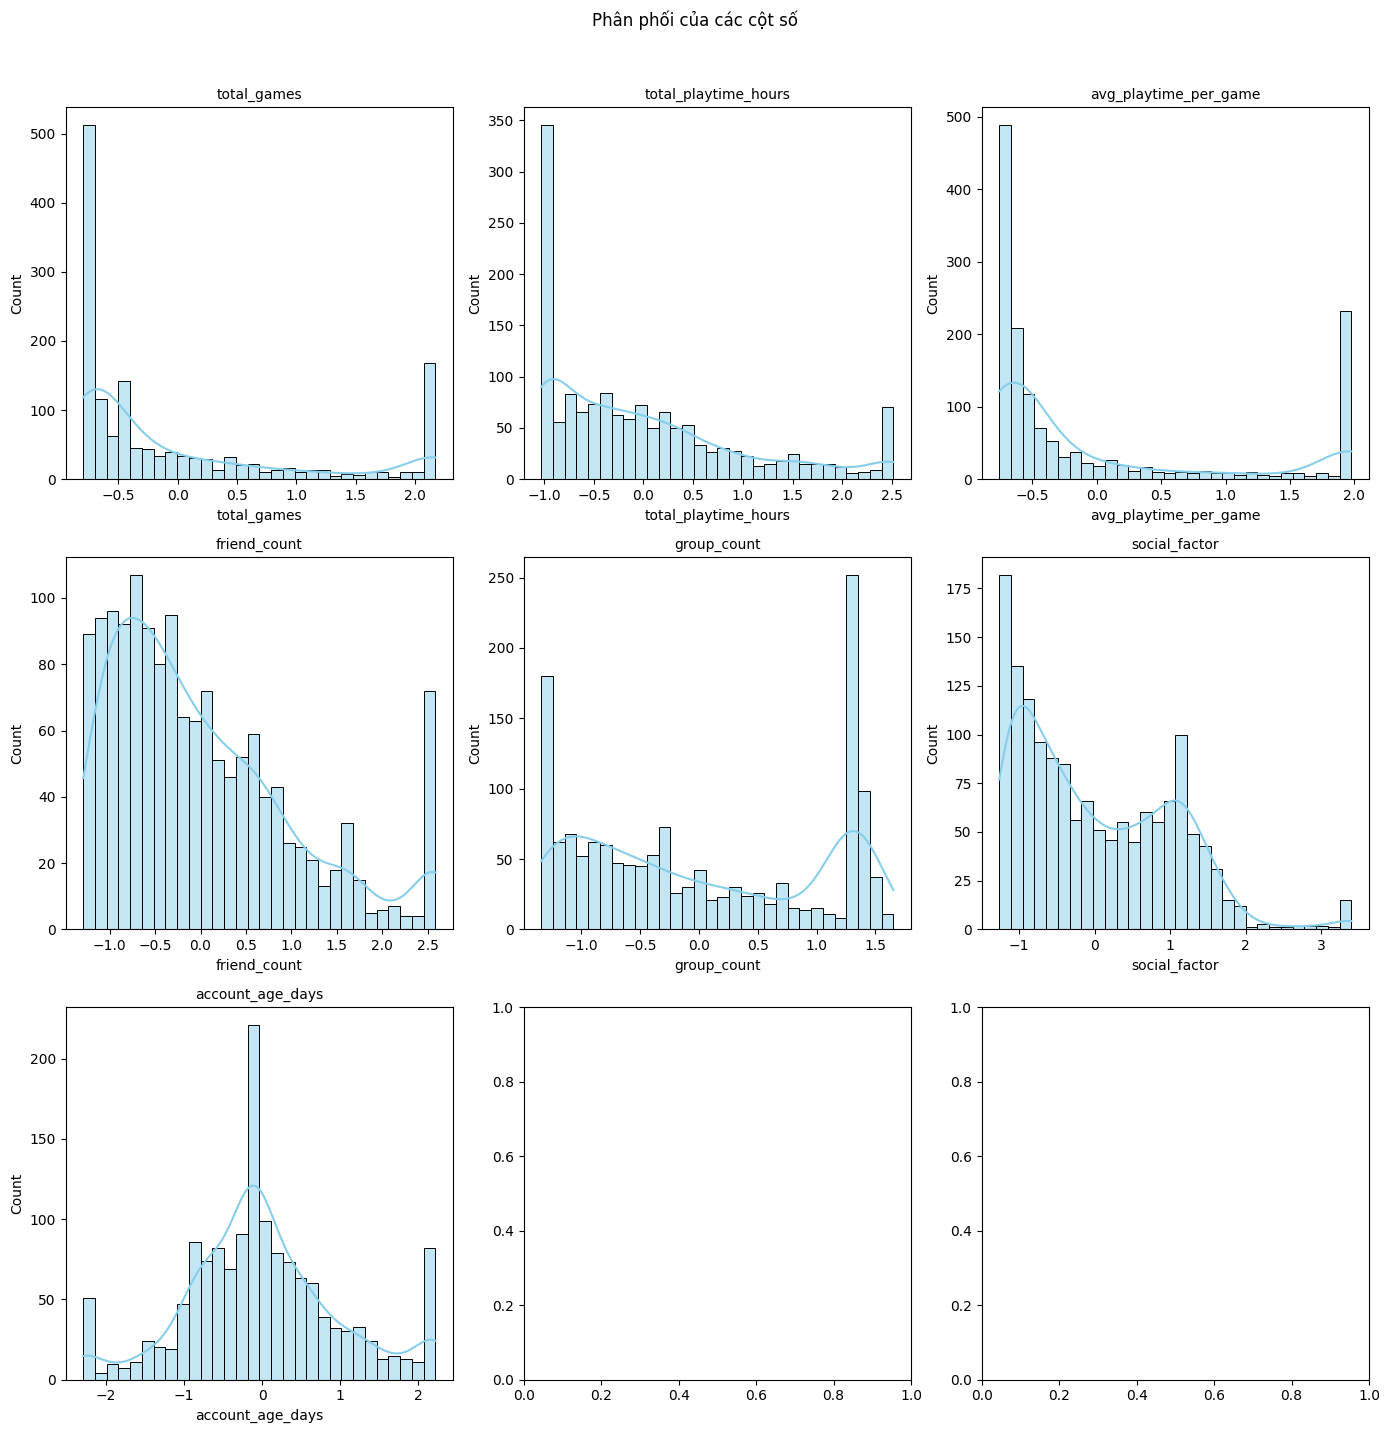

C:\Users\Loc\AppData\Local\Temp\ipykernel_8908\4253089405.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel', ax=axes[i])
C:\Users\Loc\AppData\Local\Temp\ipykernel_8908\4253089405.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel', ax=axes[i])
C:\Users\Loc\AppData\Local\Temp\ipykernel_8908\4253089405.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel', ax=axes[i])
C:\Users\Loc\AppData\Local\Temp\ipykernel_8908\4253089405.py:25: Futur

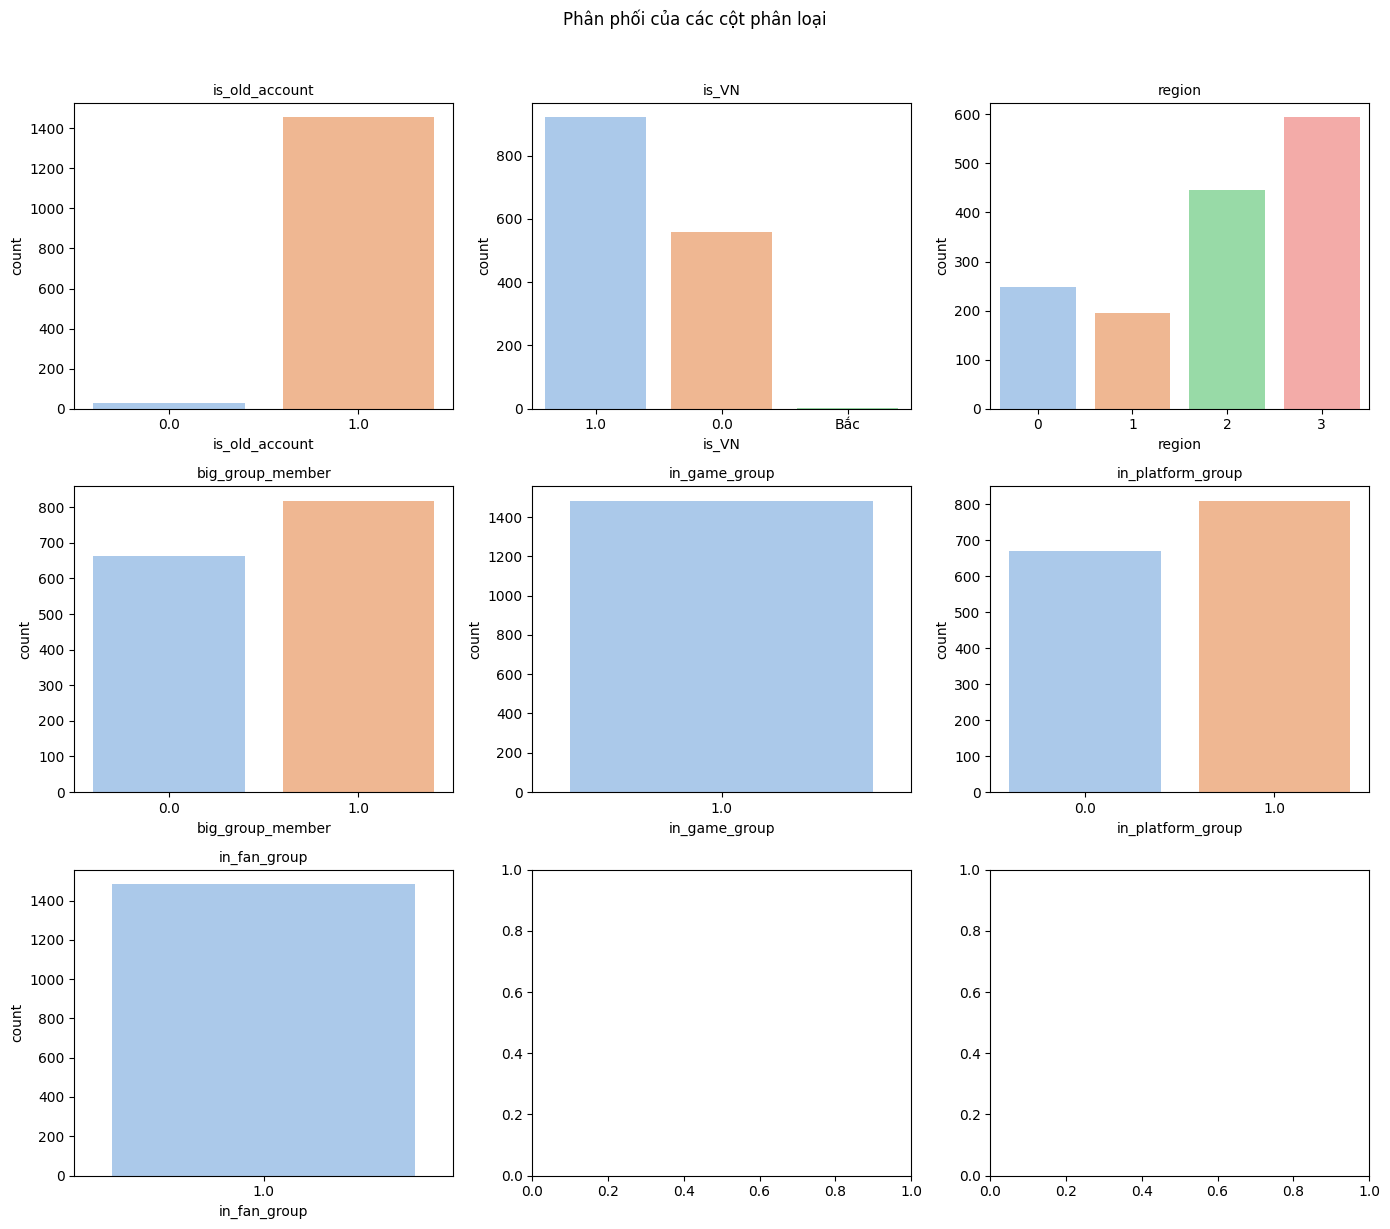

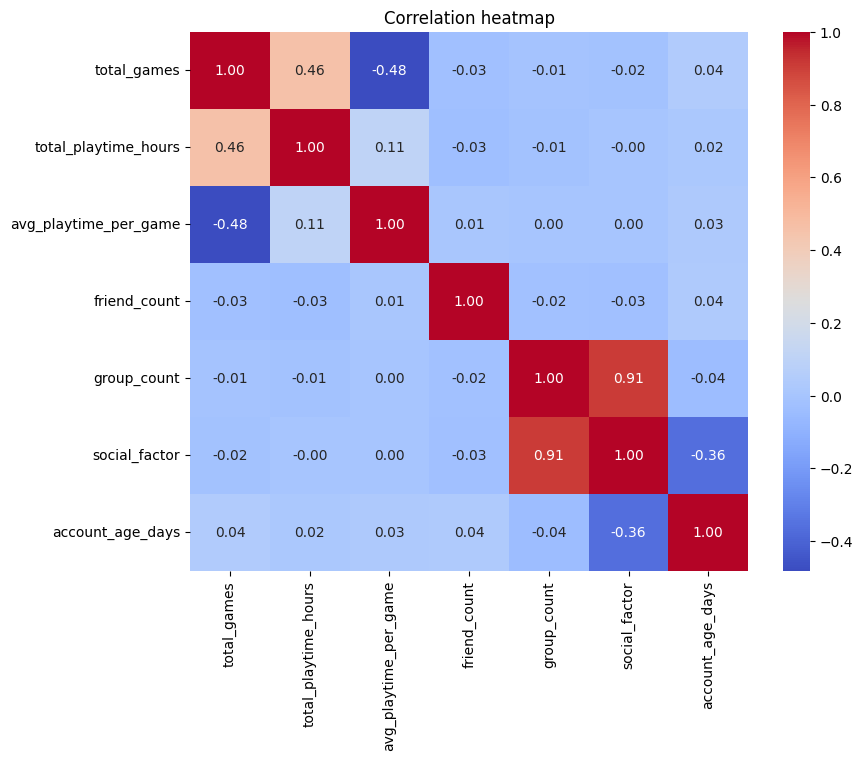

In [7]:
num_cols = [
    "total_games","total_playtime_hours","avg_playtime_per_game",
    "friend_count","group_count","social_factor","account_age_days"
]

cat_cols = ["is_old_account","is_VN","region","big_group_member",
            "in_game_group","in_platform_group","in_fan_group"]

fig, axes = plt.subplots(3, 3, figsize=(14, 14)) 
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=30, kde=True, color='skyblue', ax=axes[i])
    axes[i].set_title(col, fontsize=10)

plt.suptitle("Phân phối của các cột số", y=1.02)
plt.tight_layout()
plt.show()

# 2. Count Plots 
fig, axes = plt.subplots(3, 3, figsize=(14, 12)) 
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, palette='pastel', ax=axes[i])
    axes[i].set_title(col, fontsize=10)
plt.suptitle("Phân phối của các cột phân loại", y=1.02)
plt.tight_layout()
plt.show()

# 3. Heatmap 
plt.figure(figsize=(9, 7))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation heatmap")
plt.show()